* **Eğitim Süresi:** 10 Epoch
* **Eğitim Başarısı:** %76.40 Train Accuracy | **%72.46 Validation Accuracy** (En iyi model: `%72.46` doğruluk ve `0.8680` Val Loss ile kaydedilmiştir.)

SqueezeNet'in orijinal 2016 makalesinde **Batch Normalization (BatchNorm)** katmanları yer almamaktadır. Ancak bu projede, modelin her bir **Fire Modülü** içerisine (Squeeze ve Expand evrişim katmanlarının hemen arkasına) **BatchNorm2d** entegre edilmiştir.

### ❓ BatchNorm Olmadan Model Neden Eğitilemedi? (Gradient Deadlock)
İlk denemelerde, orijinal tasarıma sadık kalınarak BatchNorm kullanılmadığında modelin **%10** (rastgele tahmin) doğruluk seviyesinde kilitlendiği ve hiçbir şey öğrenemediği görülmüştür. Bunun temel sebepleri şunlardır:

1. **Gradyan Kaybolması (Gradient Vanishing):** SqueezeNet parametre sayısı az, dar ama derin bir ağdır. BatchNorm olmadığında, katmanlardan geçen aktivasyonların dağılımı derinleştikçe bozulur. Gradyanlar kararsız hale gelerek sıfıra yaklaşır ve ağırlıklar güncellenemez.
2. **Dying ReLU Problemi:** Çıkış katmanında ve Fire modüllerinde kullanılan ReLU aktivasyon fonksiyonları, normalize edilmemiş negatif değerlerle karşılaştığında gradyan akışını tamamen kesmiştir.
3. **SGD Kararsızlığı:** Orijinal makalede kullanılan SGD (Momentum=0.9) optimizer'ı, düzensiz bir kayıp yüzeyinde yönünü bulamamış ve yerel minimum çukurlarına saplanıp kalmıştır.

### 💡 BatchNorm'un Sağladığı Avantajlar:
* **Lissage (Pürüzsüzleştirme):** Kayıp yüzeyini pürüzsüzleştirerek gradyanların ağ boyunca kararlı bir şekilde akmasını sağladı.
* **Hızlı Yakınsama :** Modelin daha 1. epoch'tan itibaren öğrenmeye başlamasını ve 10 epoch gibi çok kısa bir sürede **%72+** başarıya ulaşmasını sağladı.
* **Regularization:** Modelin aşırı öğrenmeye kaçmasını engelleyerek Train ve Val başarılarının dengeli gitmesine yardımcı oldu.

In [1]:
import matplotlib.pyplot as plt
import torch
import torchvision
from torch import nn
from torchvision import transforms, datasets
from torchvision.datasets import ImageFolder
from torchinfo import summary
from torch.utils.data import DataLoader, Subset
import os
import time

In [2]:
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
device

'cuda'

In [3]:

data_dir = "imagenette2-320"

train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")

train_dataset = ImageFolder(root=train_dir, transform=transforms.ToTensor())
val_dataset = ImageFolder(root=val_dir, transform=transforms.ToTensor())

In [4]:
len(train_dataset)

9469

In [5]:
len(val_dataset)

3925

In [6]:
img, label = train_dataset[3031]

In [7]:
label

3

In [8]:
img

tensor([[[1.0000, 1.0000, 1.0000,  ..., 0.9882, 0.9882, 0.9882],
         [1.0000, 1.0000, 1.0000,  ..., 0.9882, 0.9882, 0.9882],
         [1.0000, 1.0000, 1.0000,  ..., 0.9882, 0.9882, 0.9882],
         ...,
         [0.8863, 0.8824, 0.8784,  ..., 0.8902, 0.8941, 0.8980],
         [0.8824, 0.8784, 0.8745,  ..., 0.8863, 0.8902, 0.8941],
         [0.8824, 0.8784, 0.8745,  ..., 0.8824, 0.8863, 0.8902]],

        [[1.0000, 1.0000, 1.0000,  ..., 0.9882, 0.9882, 0.9882],
         [1.0000, 1.0000, 1.0000,  ..., 0.9882, 0.9882, 0.9882],
         [1.0000, 1.0000, 1.0000,  ..., 0.9882, 0.9882, 0.9882],
         ...,
         [0.8824, 0.8784, 0.8745,  ..., 0.8510, 0.8549, 0.8588],
         [0.8784, 0.8745, 0.8706,  ..., 0.8471, 0.8510, 0.8549],
         [0.8784, 0.8745, 0.8706,  ..., 0.8431, 0.8471, 0.8510]],

        [[1.0000, 1.0000, 1.0000,  ..., 0.9412, 0.9412, 0.9412],
         [1.0000, 1.0000, 1.0000,  ..., 0.9412, 0.9412, 0.9412],
         [1.0000, 1.0000, 1.0000,  ..., 0.9412, 0.9412, 0.

In [9]:
img.shape

torch.Size([3, 320, 836])

In [10]:
class Fire(nn.Module):
    def __init__(self, in_channels = 3, s1 = 16, e1 = 64, e3 = 64):
        super().__init__()
        self.squeeze = nn.Conv2d(
            in_channels = in_channels,
            out_channels = s1,
            kernel_size = 1,
            padding = 0
            )
        self.bn_s = nn.BatchNorm2d(s1)
        self.activation = nn.ReLU(inplace = True)

        self.expand1 = nn.Conv2d(in_channels = s1,
                                out_channels = e1,
                                kernel_size = 1,
                                padding = 0)
        self.bn_e1 = nn.BatchNorm2d(e1)
        self.expand3 = nn.Conv2d(in_channels = s1,
                                out_channels = e3,
                                kernel_size = 3,
                                padding = 1)
        self.bn_e3 = nn.BatchNorm2d(e3)
    def forward(self, x):
        squeeze_out = self.activation(self.squeeze(x))
        squeeze_out = self.bn_s(squeeze_out)

        out_e1 = self.activation(self.expand1(squeeze_out))
        out_e1 = self.bn_e1(out_e1)

        out_e3 = self.activation(self.expand3(squeeze_out))
        out_e3 = self.bn_e3(out_e3)
        return torch.cat([out_e1, out_e3], dim = 1)

In [11]:
class SqueezeNet(nn.Module):
    def __init__(self, classes = 10):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels = 3,
                                out_channels = 96,
                                kernel_size = 7,
                                stride = 2,
                                padding = 3)
        self.relu1 = nn.ReLU(inplace=True)
        self.maxpool1 = nn.MaxPool2d(3, stride = 2)

        self.fire2 = Fire(in_channels = 96, s1 = 16, e1 = 64, e3 = 64)
        self.fire3 = Fire(in_channels = 128, s1 = 16, e1 = 64, e3 = 64)
        self.fire4 = Fire(in_channels = 128, s1 = 32, e1 = 128, e3 = 128)
        self.maxpool4 = nn.MaxPool2d(3, stride = 2)

        self.fire5 = Fire(in_channels = 256, s1 = 32, e1 = 128, e3 = 128)
        self.fire6 = Fire(in_channels = 256, s1 = 48, e1 = 192, e3 = 192)
        self.fire7 = Fire(in_channels = 384, s1 = 48, e1 = 192, e3 = 192)
        self.fire8 = Fire(in_channels = 384, s1 = 64, e1 = 256, e3 = 256)
        self.maxpool8 = nn.MaxPool2d(3, stride = 2)

        self.fire9 = Fire(in_channels = 512, s1 = 64, e1 = 256, e3 = 256)

        self.dropout =nn.Dropout(p=0.5)

        self.conv10 = nn.Conv2d(in_channels = 512,
                                out_channels = classes,
                                kernel_size = 1,
                                stride = 1)
        self.relu10 = nn.ReLU(inplace = True)
        self.avgpool10 = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, x):
        first = self.maxpool1(self.relu1(self.conv1(x)))
        blok_1 = self.maxpool4(self.fire4(self.fire3(self.fire2(first))))
        blok_2 = self.maxpool8(self.fire8(self.fire7(self.fire6(self.fire5(blok_1)))))


        blok_3 = self.avgpool10(self.relu10(self.conv10(self.dropout(self.fire9(blok_2)))))  # batch,10,1,1
        return torch.flatten(blok_3, 1)  # (batch,10) 0. indekse dokunma flattena 1den başla

In [12]:
img = img.permute(1,2,0)
img.shape

torch.Size([320, 836, 3])

In [13]:
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(size = 224, scale=(0.8, 1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [14]:
train_data = ImageFolder(root = "imagenette2-320/train", transform = train_transforms)
val_data = ImageFolder(root = "imagenette2-320/val", transform = val_transforms)

train_loader = DataLoader(train_data, batch_size = 32, shuffle = True)
val_loader = DataLoader(val_data, batch_size = 32, shuffle = False)

In [15]:
model = SqueezeNet()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    params=model.parameters(),
    lr=0.01,
    momentum = 0.9
)

In [16]:
img, label = next(iter(train_loader))

out = model(img)

print(out[:5])
print(label[:5])

tensor([[0.2730, 0.3900, 0.1907, 0.2124, 0.1916, 0.2446, 0.3161, 0.2746, 0.2595,
         0.2552],
        [0.3324, 0.3365, 0.2268, 0.2051, 0.2496, 0.2236, 0.1873, 0.3853, 0.2605,
         0.3367],
        [0.3698, 0.2981, 0.3095, 0.2357, 0.3180, 0.3040, 0.2109, 0.3021, 0.2867,
         0.3173],
        [0.2705, 0.2228, 0.5250, 0.2648, 0.4068, 0.3611, 0.4272, 0.4972, 0.3076,
         0.2503],
        [0.2647, 0.1495, 0.4430, 0.5674, 0.5334, 0.3025, 0.4198, 0.4767, 0.4400,
         0.3214]], grad_fn=<SliceBackward0>)
tensor([1, 5, 6, 9, 3])


In [17]:
EPOCHS = 10
torch.manual_seed(42)

train_losses = []
val_losses = []
best_val_loss = float("inf")

model = model.to(device)

for epoch in range(EPOCHS):
    epoch_start_time = time.time()

    train_epoch_loss = 0
    train_correct = 0
    train_total = 0

    val_epoch_loss = 0
    val_correct = 0
    val_total = 0

    # train
    model.train()
    for img, label in train_loader:
        img = img.to(device)
        label = label.to(device)

        optimizer.zero_grad()

        outputs = model(img)
        loss = loss_fn(outputs, label)

        loss.backward()
        optimizer.step()

        train_epoch_loss += loss.item() * img.size(0)   # batch boyutunu çarparak ekliyoruz ki ortalamayı alalım
        _, preds = torch.max(outputs, dim=1)
        train_correct += (preds == label).sum().item()
        train_total += label.size(0)

    # validation
    model.eval()
    with torch.no_grad():
        for img, label in val_loader:
            img = img.to(device)
            label = label.to(device)

            outputs = model(img)
            loss = loss_fn(outputs, label)

            val_epoch_loss += loss.item() * img.size(0)
            _, preds = torch.max(outputs, dim=1)
            val_correct += (preds == label).sum().item()
            val_total += label.size(0)


    epoch_train_loss = train_epoch_loss / len(train_loader.dataset)
    epoch_train_acc = train_correct / train_total
    epoch_val_loss = val_epoch_loss / len(val_loader.dataset)
    epoch_val_acc = val_correct / val_total

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    epoch_end_time = time.time()
    elapsed_time = epoch_end_time - epoch_start_time
    mins, secs = divmod(elapsed_time, 60)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Süre: {int(mins)}dk {int(secs)}sn -> "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc*100:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc*100:.2f}%")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_squeezenet.pth")
        print(f"  --> Yeni en iyi model kaydedildi! (Val Loss: {best_val_loss:.4f})")

    print("-" * 40)

Epoch [1/10] | Süre: 1dk 31sn -> Train Loss: 1.8213, Train Acc: 37.12% | Val Loss: 1.8892, Val Acc: 37.91%
  --> Yeni en iyi model kaydedildi! (Val Loss: 1.8892)
----------------------------------------
Epoch [2/10] | Süre: 1dk 29sn -> Train Loss: 1.3730, Train Acc: 54.65% | Val Loss: 1.4106, Val Acc: 54.37%
  --> Yeni en iyi model kaydedildi! (Val Loss: 1.4106)
----------------------------------------
Epoch [3/10] | Süre: 1dk 31sn -> Train Loss: 1.1917, Train Acc: 60.62% | Val Loss: 1.1080, Val Acc: 64.48%
  --> Yeni en iyi model kaydedildi! (Val Loss: 1.1080)
----------------------------------------
Epoch [4/10] | Süre: 1dk 28sn -> Train Loss: 1.0726, Train Acc: 65.41% | Val Loss: 1.2830, Val Acc: 57.48%
----------------------------------------
Epoch [5/10] | Süre: 1dk 28sn -> Train Loss: 0.9817, Train Acc: 68.43% | Val Loss: 1.3050, Val Acc: 57.83%
----------------------------------------
Epoch [6/10] | Süre: 1dk 27sn -> Train Loss: 0.9034, Train Acc: 70.93% | Val Loss: 1.0988, Val 

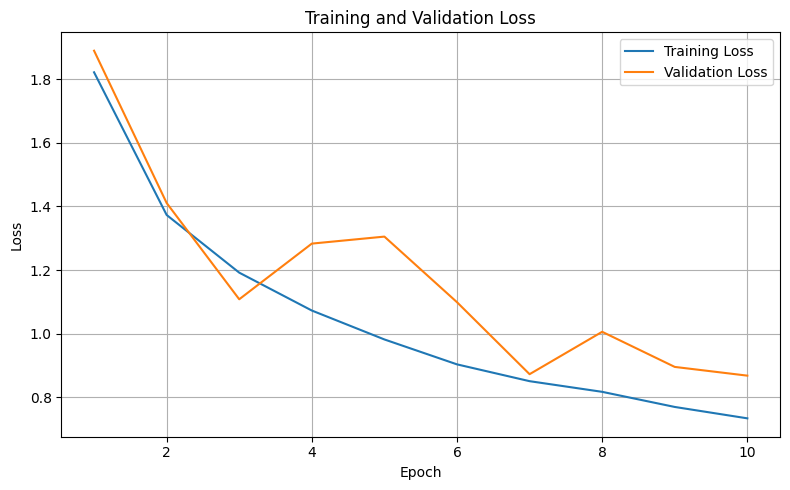

In [26]:
plt.figure(figsize=(8, 5))

# Plotting training and validation loss
plt.plot(range(1, EPOCHS + 1), train_losses, label='Training Loss')
plt.plot(range(1, EPOCHS + 1), val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()